# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Stella!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [13]:
from plot_bowtie import plot_bowtie_blocks, plot_bowtie_fluxes

## Load data

In [14]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
BIPARTITE_FOLDER=HOME+'guarino_files/'

# Looking into the abyss

In [15]:
guarino_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

### Name of the various dicos

In [16]:
with open(BIPARTITE_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()

In [17]:
cacca

['quirinale\n',
 '5: journalists & Media\n',
 '2: M5S\n',
 '0: journalists & IV & Azione & +Europa & Media\n',
 '4: Lega & FDI\n',
 '1: PD\n',
 '3: Media & journalists\n',
 '6: FI\n',
 '\n',
 'crisi\n',
 '1: Lega & FDI & FI\n',
 '2: M5S & journalists\n',
 '0: journalists & IV & Media & Azione & +Europa\n',
 '4: Media & journalists\n',
 '3: PD\n',
 '\n',
 'ita_elections\n',
 '1: PD & Media & +Europa & journalists\n',
 '2: M5S & Media\n',
 '3: journalists & IV & Azione\n',
 '0: Lega & FDI & FI\n',
 '4: journalists & Media (1)\n',
 '5: Media\n',
 '6: journalists & Media (2)\n',
 '\n']

In [18]:
with open(BIPARTITE_FOLDER+guarino_files[6], 'rb') as f:
    cacca = pickle.load(f)

In [19]:
cacca

{np.int64(1): 'Lega & FDI & FI',
 np.int64(2): 'M5S & journalists',
 np.int64(0): 'journalists & IV & Media & Azione & +Europa',
 np.int64(4): 'Media & journalists',
 np.int64(3): 'PD'}

The pickle is what I need.

### From Guarino to my (actually, Sonnet's...) standards

In [20]:
cacca=np.genfromtxt(BIPARTITE_FOLDER+guarino_files[1], delimiter=',', dtype=int, skip_header=1)
header = np.genfromtxt(BIPARTITE_FOLDER+guarino_files[1], delimiter=',', dtype=str, max_rows=1)
header=[str(h) for h in header]

In [21]:
guarino_files[1]

'crisi_dico_0_bowtie_sizes.csv'

In [22]:
header

['IN', 'IN-TENDRILS', 'LSCC', 'OTHERS', 'OUT', 'OUT-TENDRILS', 'TUBES']

In [23]:
with open(PVALUE_FOLDER+'crisi_dico0_pvalues_blocks_0.pkl', 'rb') as f:
    block_dict_0 = pickle.load(f)
with open(PVALUE_FOLDER+'crisi_dico0_pvalues_fluxes_0.pkl', 'rb') as f:
    flux_dict_0 = pickle.load(f)

In [24]:
block_dict_0

defaultdict(dict,
            {'OUT': {'obs': 33640,
              'mean_sim': 34817.4252,
              'std_sim': np.float64(306.5698152219566),
              'tail': 'left',
              'p_value': 0.0008},
             'INTENDRILS': {'obs': 14687,
              'mean_sim': 4390.776,
              'std_sim': np.float64(290.7526031250675),
              'tail': 'right',
              'p_value': 0.0},
             'SCC': {'obs': 3513,
              'mean_sim': 3376.621,
              'std_sim': np.float64(45.93500363557738),
              'tail': 'right',
              'p_value': 0.0032},
             'OUTTENDRILS': {'obs': 2150,
              'mean_sim': 1261.5888,
              'std_sim': np.float64(38.8600323540792),
              'tail': 'right',
              'p_value': 0.0},
             'OTHERS': {'obs': 2237,
              'mean_sim': 160.8636,
              'std_sim': np.float64(15.596069858781837),
              'tail': 'right',
              'p_value': 0.0},
             '

In [25]:
block_dict_bipartite={}

for i, name in enumerate(header):
    if name=='LSCC':
        key='SCC'
    else:
        key=name.replace('-','')
    block_dict_bipartite[key] = {}
    block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
    block_dict_bipartite[key]['sample']=cacca[:,i]
    _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
    _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
    block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
    _median=np.median(block_dict_bipartite[key]['sample'])
    if _median>block_dict_bipartite[key]['obs']:
        block_dict_bipartite[key]['tail']='right'
    else:
        block_dict_bipartite[key]['tail']='left'
    

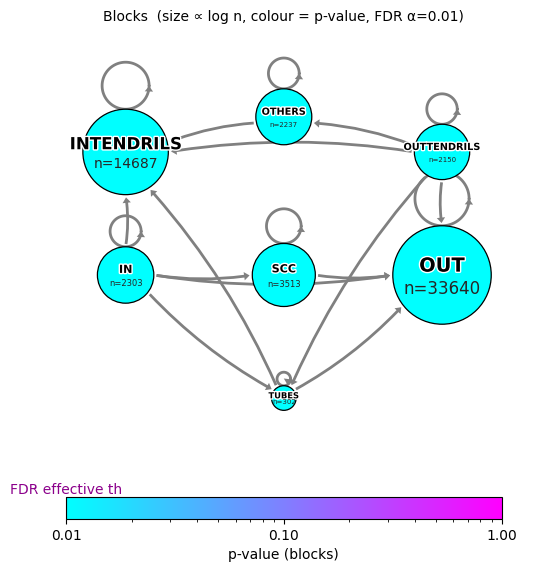

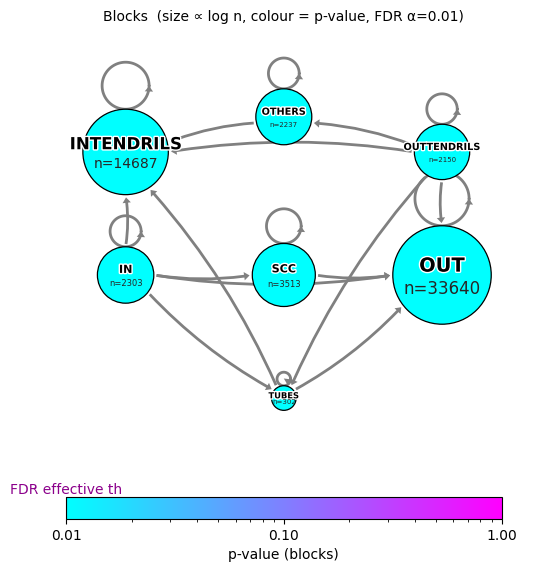

In [26]:
plot_bowtie_blocks(block_dict_bipartite, flux_dict_0, ALPHA)

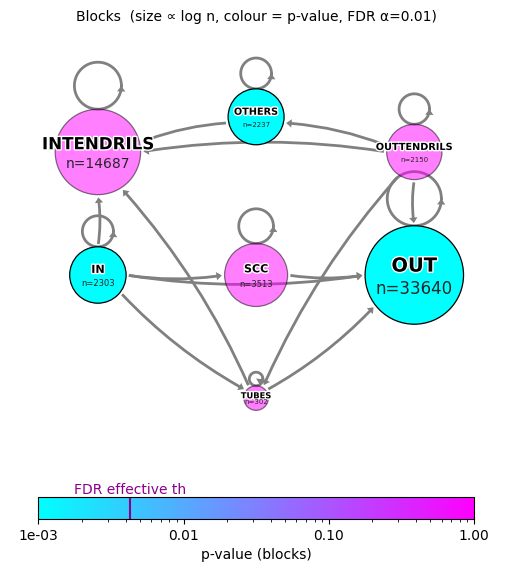

In [27]:
right_tailed_blocks={}
for key, item in block_dict_bipartite.items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, flux_dict_0, 0.01)
plt.show()

# Plots

## Functions

In [28]:
# by default, it uses pvalues_blocks_0.pkl 
def guarino2dict_blocks(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    # load the "monopartite" dict
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_0.pkl', 'rb') as f:
        block_dict_0 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_0.pkl', 'rb') as f:
        flux_dict_0 = pickle.load(f)

    block_dict_bipartite={}

    for i, name in enumerate(header):
        if name=='LSCC':
            key='SCC'
        else:
            key=name.replace('-','')
        block_dict_bipartite[key] = {}
        block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
        block_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
        block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
        _median=np.median(block_dict_bipartite[key]['sample'])
        if _median>block_dict_bipartite[key]['obs']:
            block_dict_bipartite[key]['tail']='left'
        else:
            block_dict_bipartite[key]['tail']='right'
    return block_dict_bipartite, block_dict_0, flux_dict_0



In [29]:
def right_tailer(block_dict):
    right_tailed_dict={}
    for key, item in block_dict.items():
        right_tailed_dict[key] = item
        if item['tail'] == 'right':
            right_tailed_dict[key]['p_value'] /=2
        else:
            right_tailed_dict[key]['p_value']=1.
    return right_tailed_dict


## Italian elections

In [30]:
labels_file=[file for file in os.listdir(BIPARTITE_FOLDER) if file.endswith('.pickle') and file.startswith('ita')][0]

In [31]:
labels=pickle.load(open(BIPARTITE_FOLDER+labels_file, 'rb'))

In [32]:
labels

{np.int64(1): 'PD & Media & +Europa & journalists',
 np.int64(2): 'M5S & Media',
 np.int64(3): 'journalists & IV & Azione',
 np.int64(0): 'Lega & FDI & FI',
 np.int64(4): 'journalists & Media (1)',
 np.int64(5): 'Media',
 np.int64(6): 'journalists & Media (2)'}

### Right-wing

In [33]:
blocks=guarino2dict_blocks('ita_elections', 0)

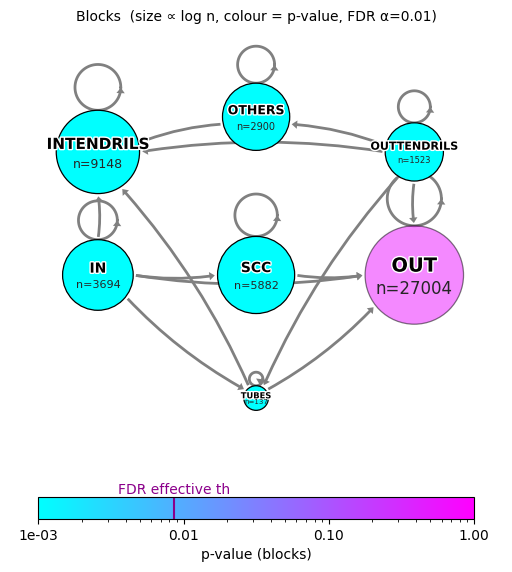

In [34]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

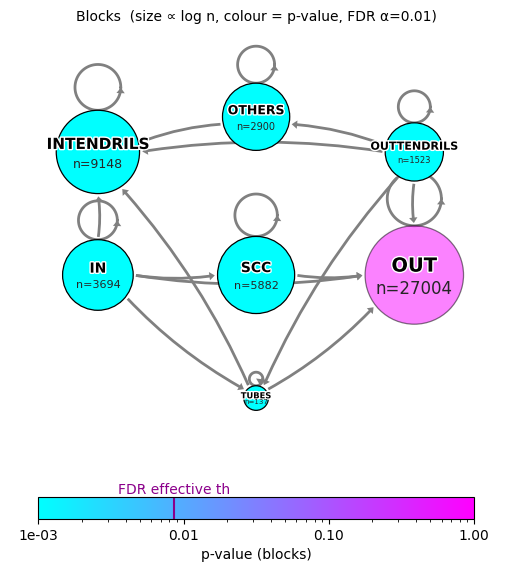

In [35]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [36]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=5.53e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [37]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=8.41e-01, tail=left
SCC: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


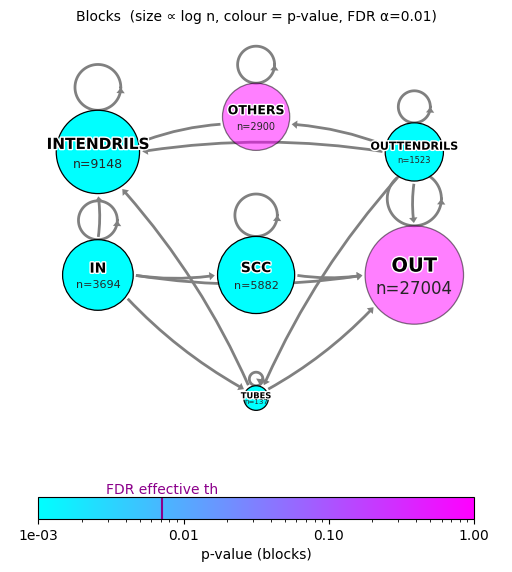

In [38]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

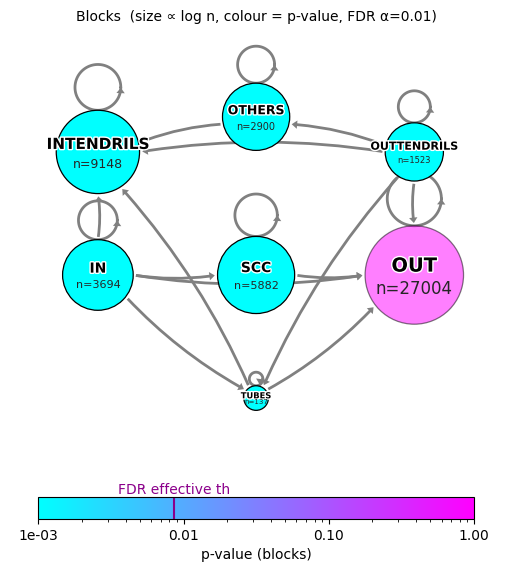

In [39]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [40]:
from scipy.stats import norm

In [41]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

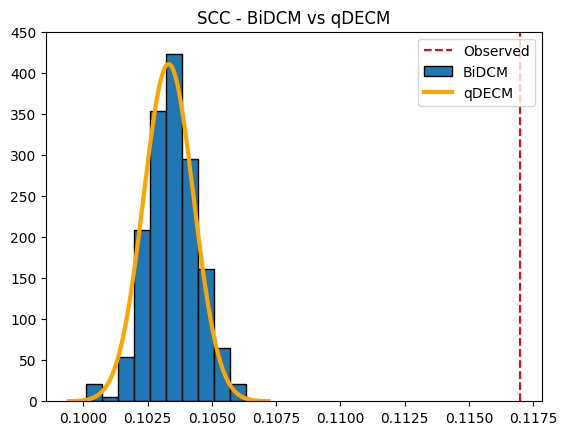

In [42]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [43]:
_block='TUBES'

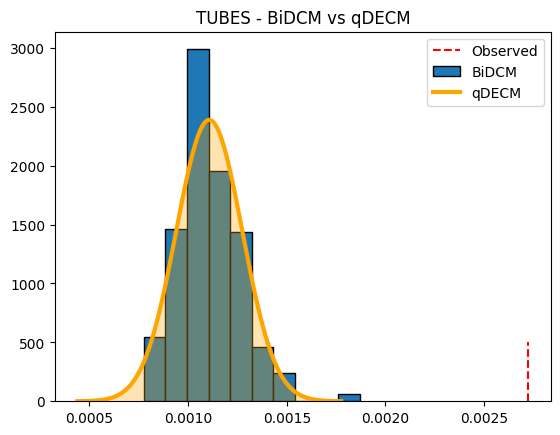

In [92]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### Italia Viva & Azione

In [44]:
blocks=guarino2dict_blocks('ita_elections', 3)

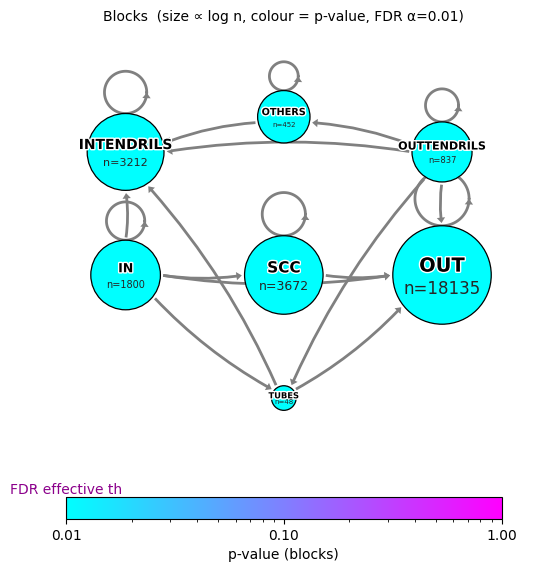

In [45]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

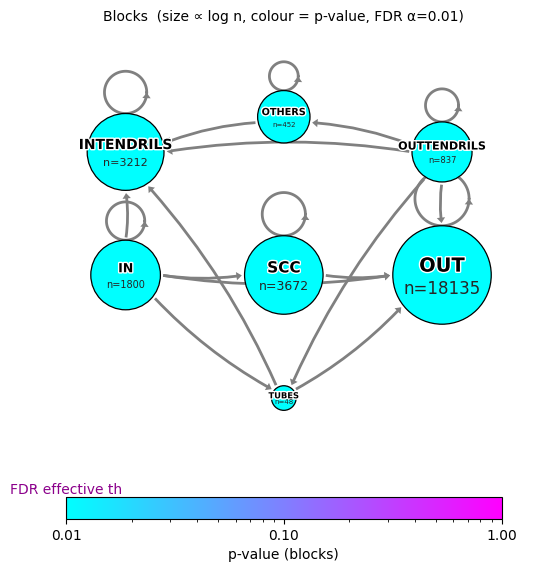

In [46]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [47]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [48]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=left
OTHERS: p-value=0.00e+00, tail=right


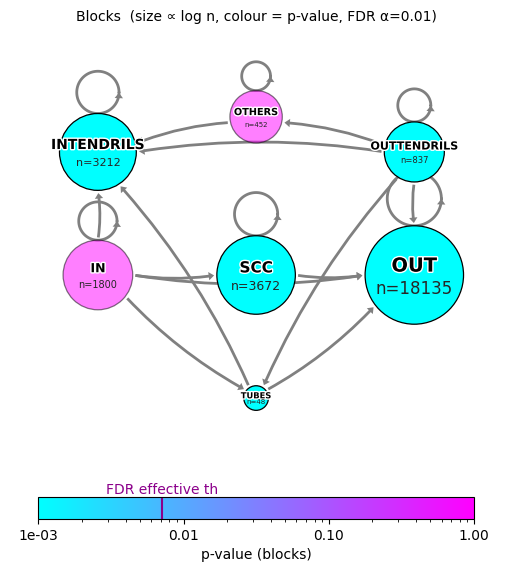

In [49]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

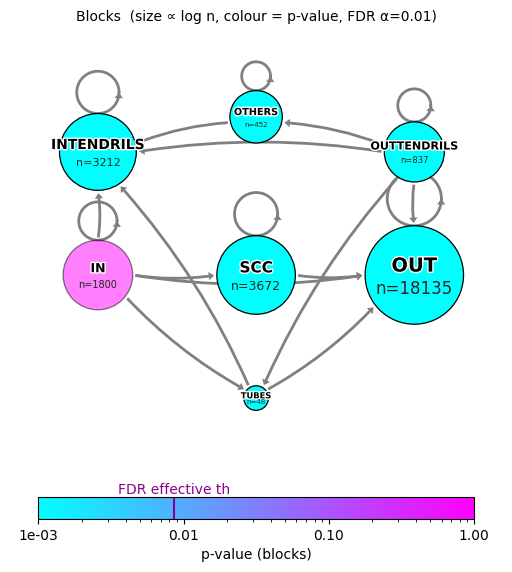

In [50]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [ ]:
from scipy.stats import norm

In [51]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

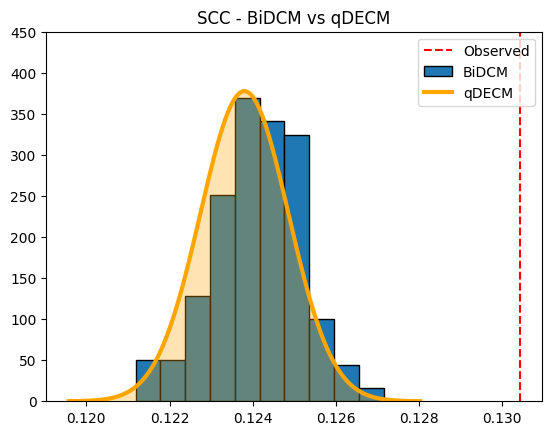

In [55]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [64]:
_block='IN'

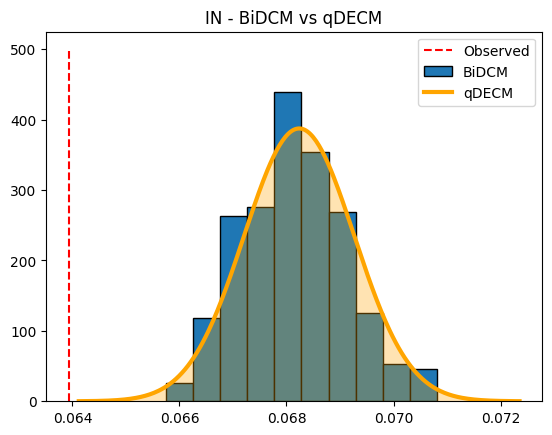

In [65]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### PD

In [66]:
blocks=guarino2dict_blocks('ita_elections', 1)

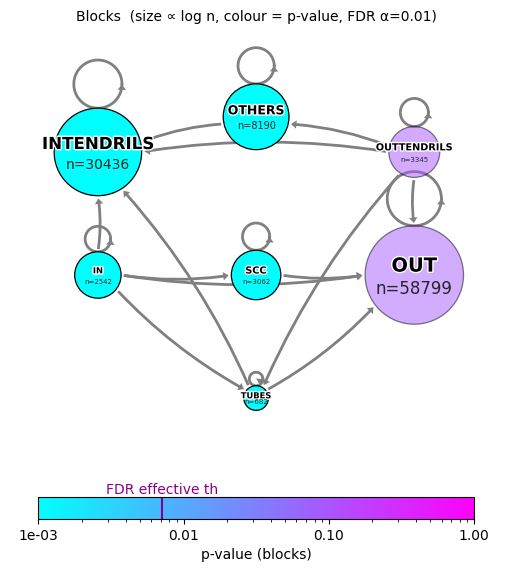

In [67]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

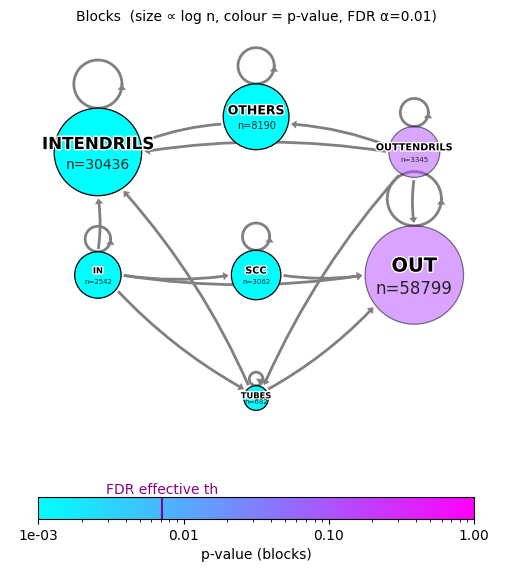

In [68]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [69]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=8.67e-02, tail=left
OUTTENDRILS: p-value=9.33e-02, tail=left
TUBES: p-value=0.00e+00, tail=right


In [70]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=1.40e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=1.22e-01, tail=left
IN: p-value=0.00e+00, tail=right


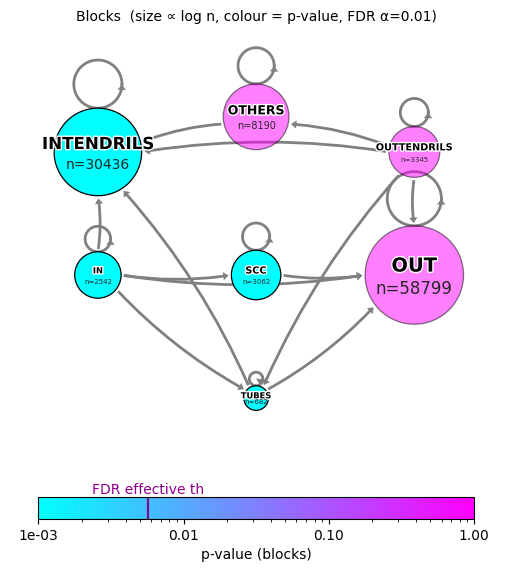

In [71]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

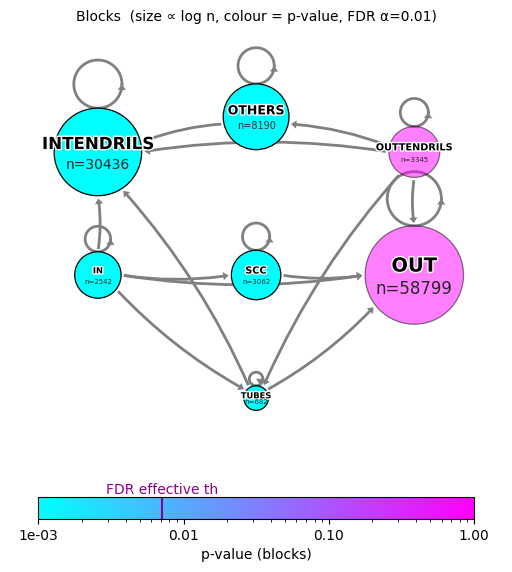

In [72]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [73]:
from scipy.stats import norm

In [74]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

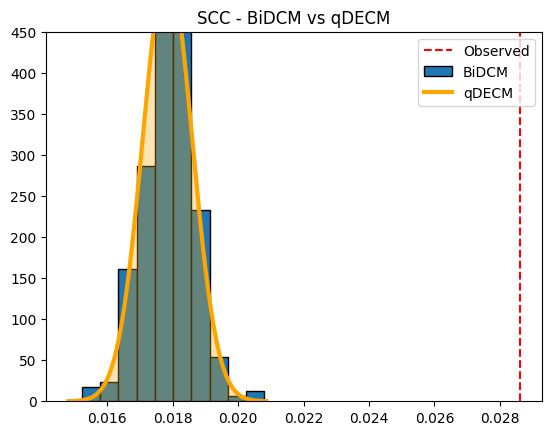

In [75]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [80]:
_block='OUTTENDRILS'

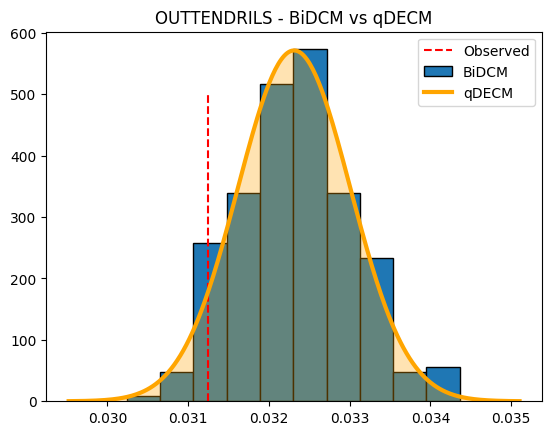

In [81]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### M5S

In [82]:
blocks=guarino2dict_blocks('ita_elections', 2)

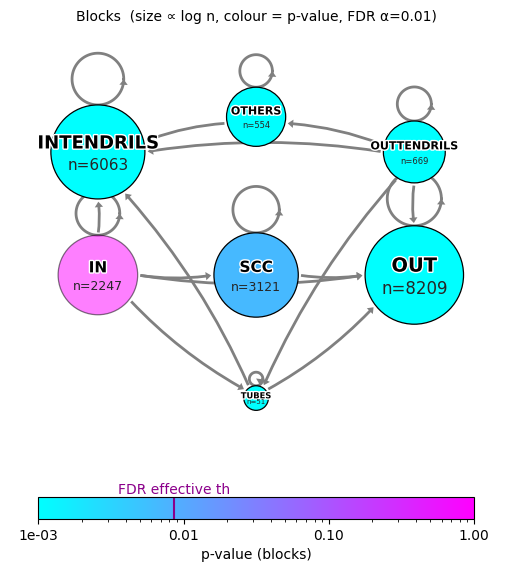

In [83]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

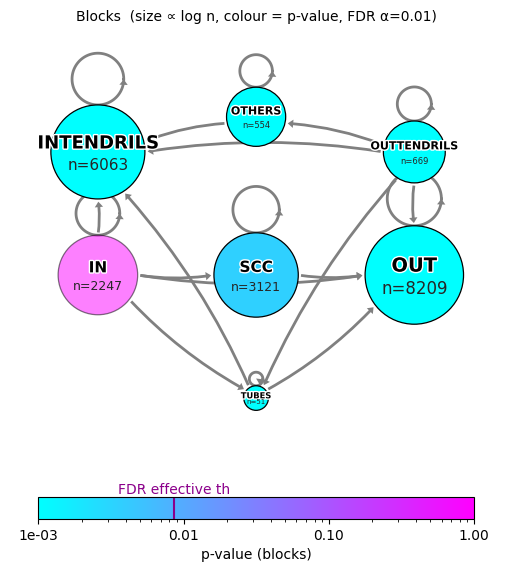

In [85]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [86]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=9.53e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=6.67e-03, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [87]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=3.60e-03, tail=right
OUT: p-value=0.00e+00, tail=left
IN: p-value=9.08e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


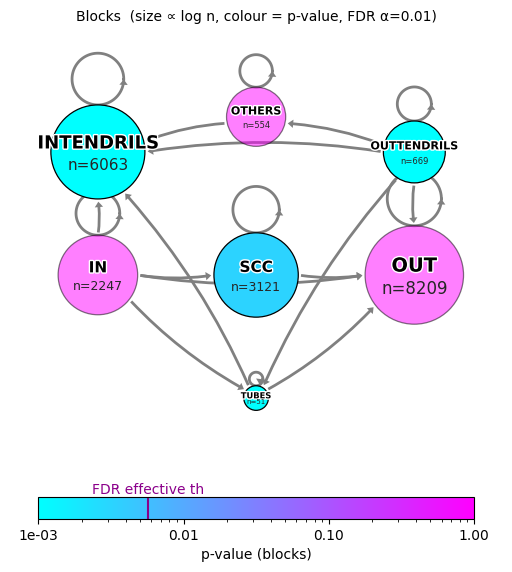

In [88]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

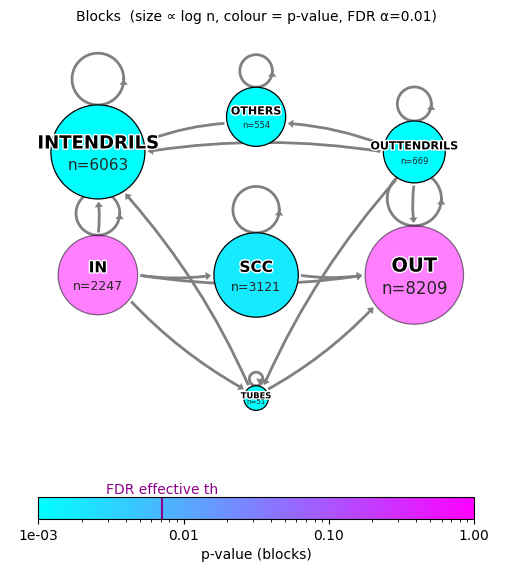

In [89]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [90]:
from scipy.stats import norm

In [91]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

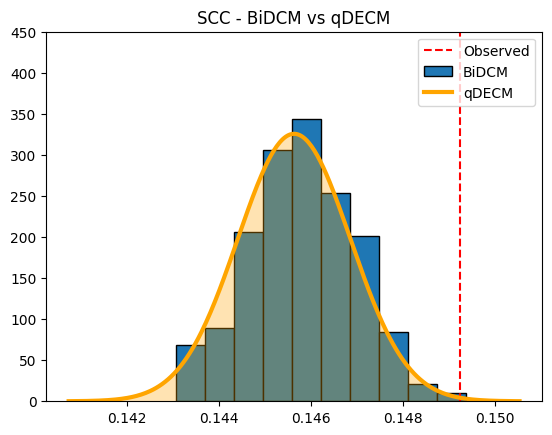

In [92]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [95]:
_block='IN'

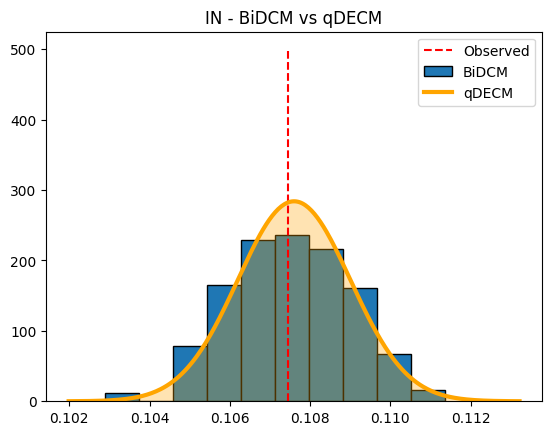

In [96]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

## Quirinale

In [97]:
labels_file=[file for file in os.listdir(BIPARTITE_FOLDER) if file.endswith('.pickle') and file.startswith('qui')][0]

In [98]:
labels=pickle.load(open(BIPARTITE_FOLDER+labels_file, 'rb'))

In [99]:
labels

{np.int64(5): 'journalists & Media',
 np.int64(2): 'M5S',
 np.int64(0): 'journalists & IV & Azione & +Europa & Media',
 np.int64(4): 'Lega & FDI',
 np.int64(1): 'PD',
 np.int64(3): 'Media & journalists',
 np.int64(6): 'FI'}

### Right-wing

In [100]:
blocks=guarino2dict_blocks('ita_elections', 4)

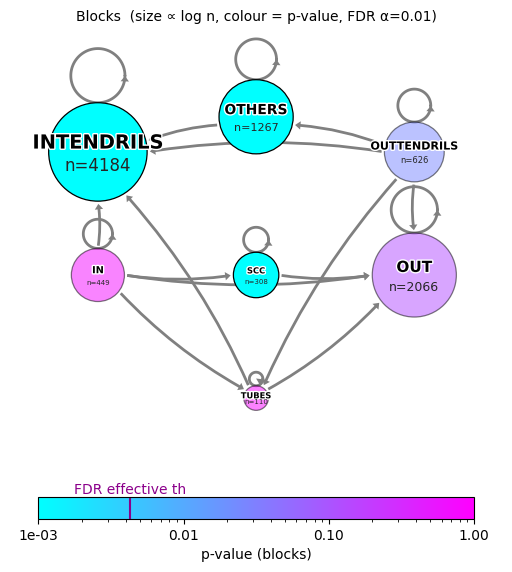

In [101]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

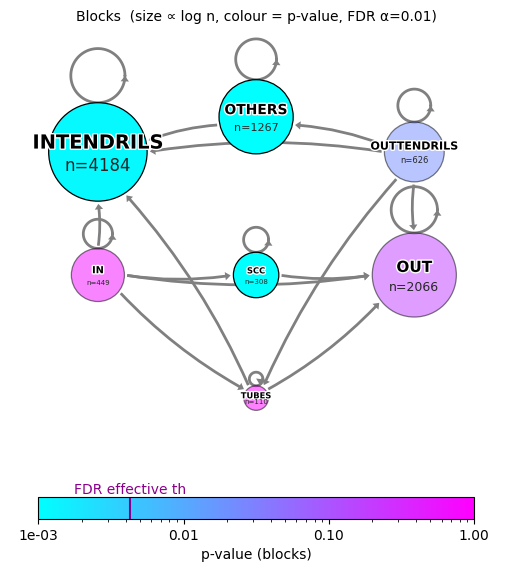

In [102]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [103]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=7.60e-01, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=1.27e-01, tail=left
OUTTENDRILS: p-value=2.67e-02, tail=right
TUBES: p-value=8.07e-01, tail=right


In [104]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUTTENDRILS: p-value=2.20e-02, tail=right
INTENDRILS: p-value=1.20e-03, tail=right
OUT: p-value=1.86e-01, tail=left
TUBES: p-value=9.30e-01, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=6.98e-01, tail=right
SCC: p-value=0.00e+00, tail=right


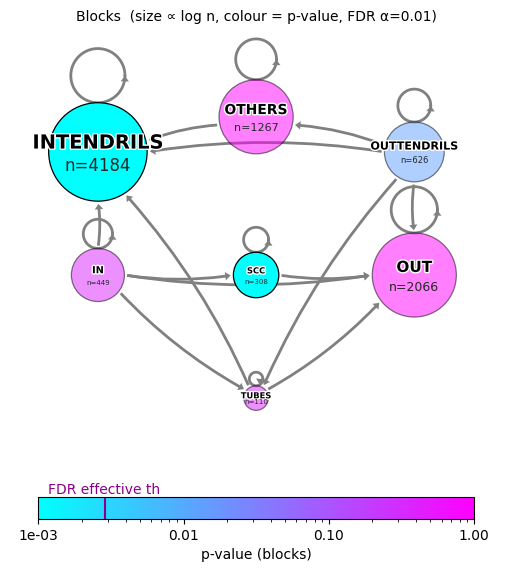

In [105]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

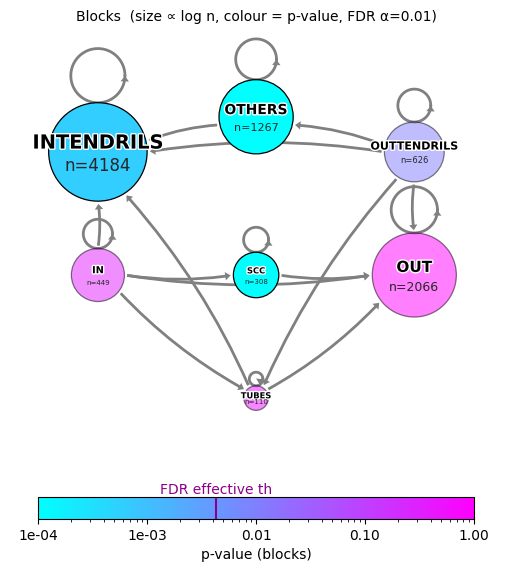

In [106]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [107]:
from scipy.stats import norm

In [108]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

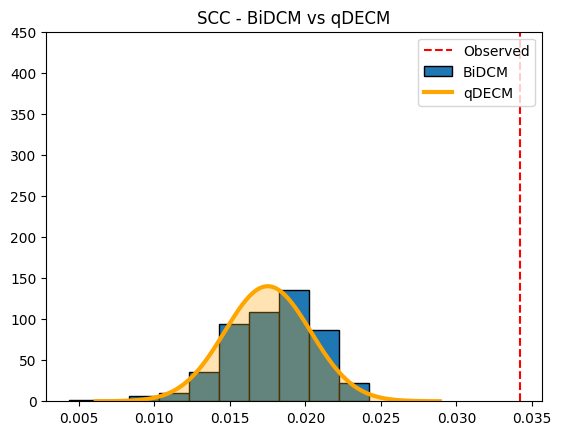

In [109]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [112]:
_block='OUTTENDRILS'

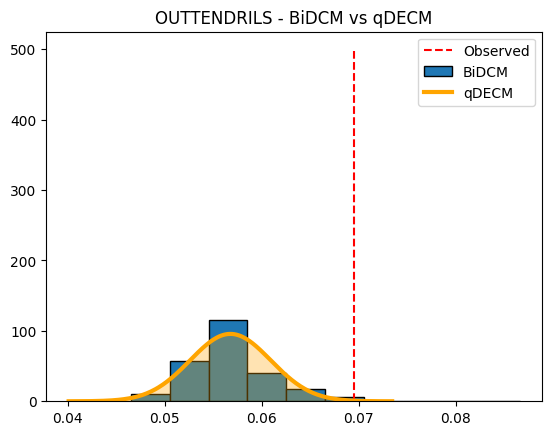

In [113]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### Italia Viva & Azione

In [114]:
blocks=guarino2dict_blocks('ita_elections', 0)

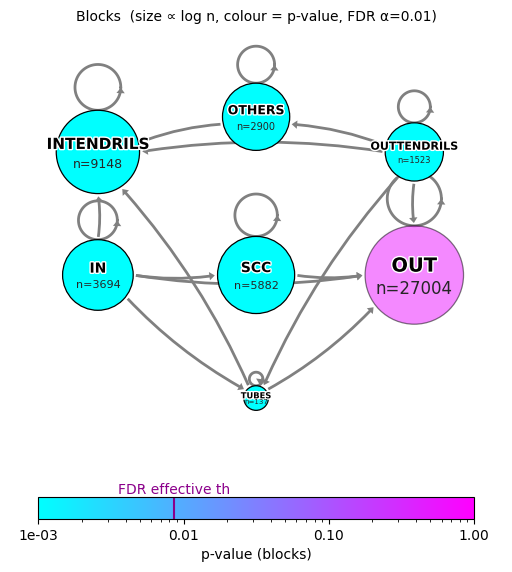

In [115]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

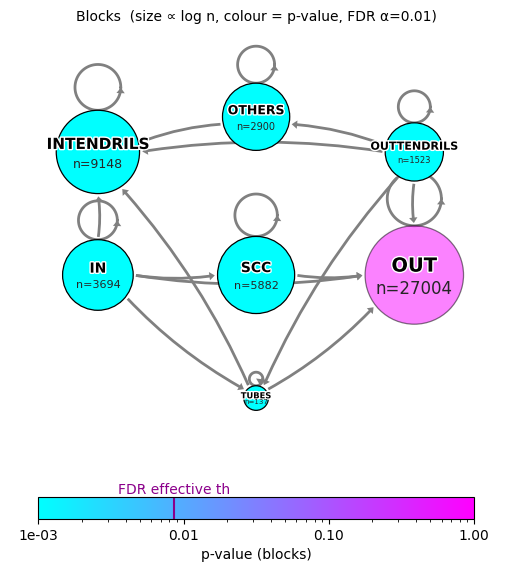

In [116]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [117]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=5.53e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [118]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=8.41e-01, tail=left
SCC: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


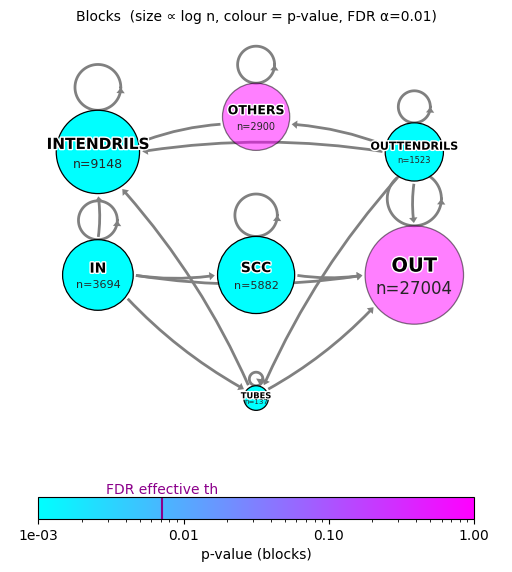

In [119]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

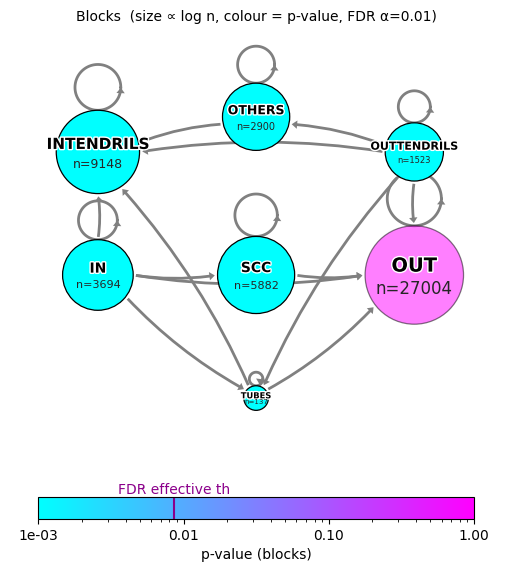

In [120]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [121]:
from scipy.stats import norm

In [122]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

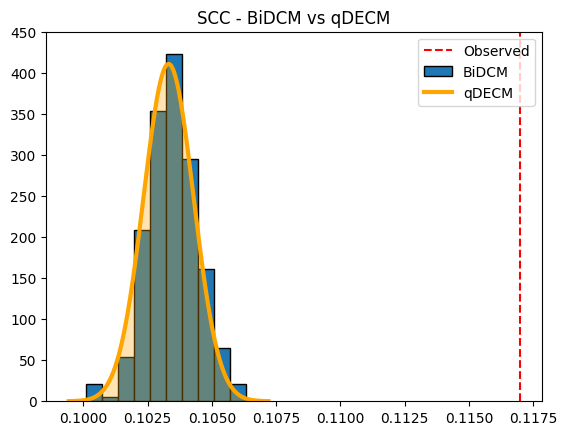

In [123]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [125]:
_block='OTHERS'

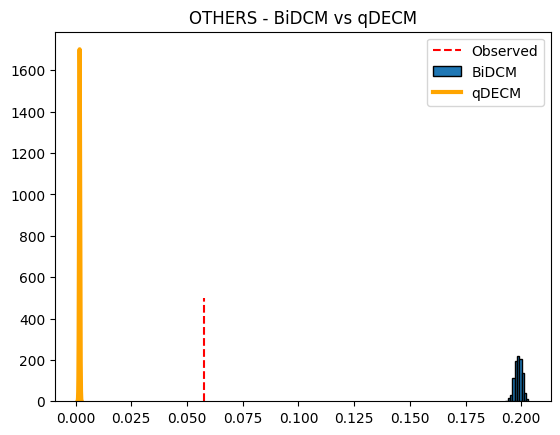

In [126]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### M5S

In [127]:
blocks=guarino2dict_blocks('ita_elections', 2)

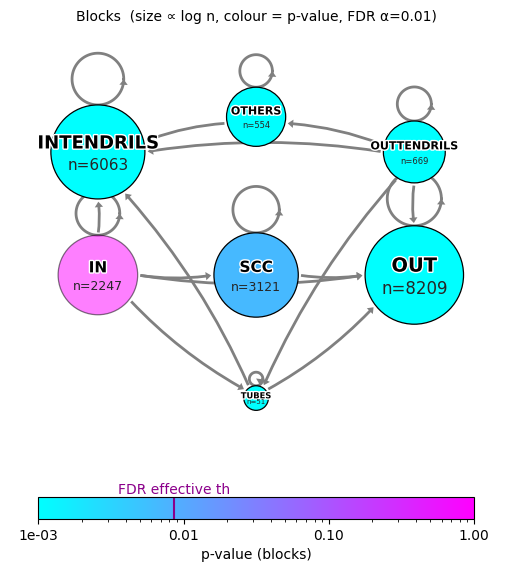

In [128]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

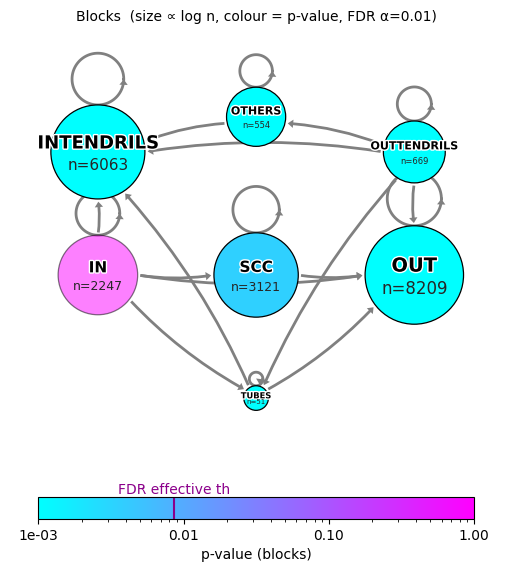

In [129]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [130]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=9.53e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=6.67e-03, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [131]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=3.60e-03, tail=right
OUT: p-value=0.00e+00, tail=left
IN: p-value=9.08e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


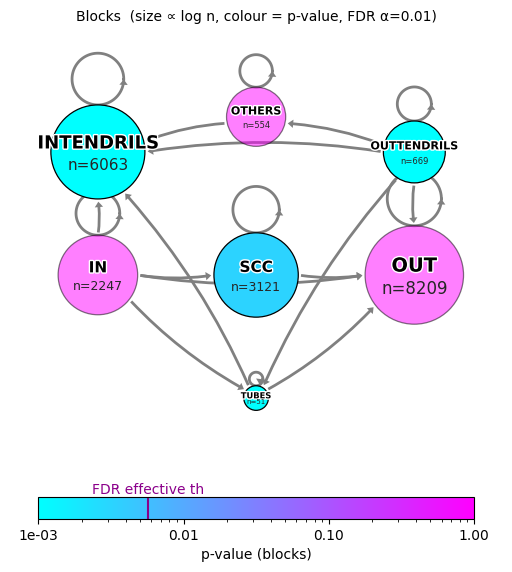

In [132]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

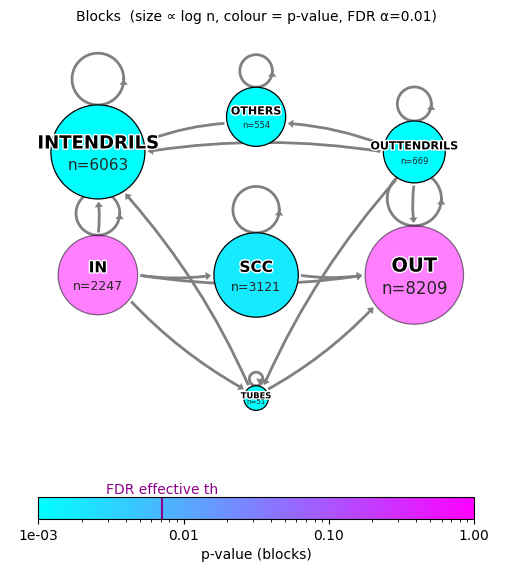

In [133]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [134]:
from scipy.stats import norm

In [135]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

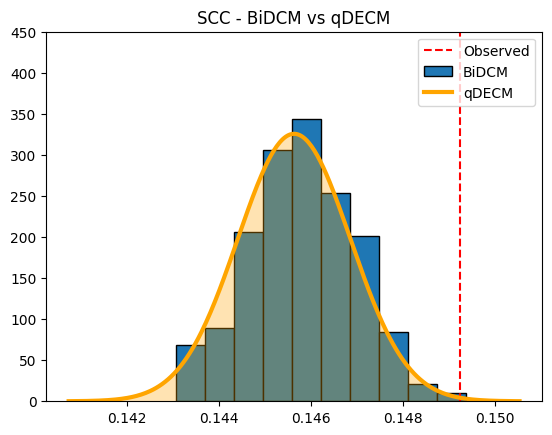

In [136]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [137]:
_block='OTHERS'

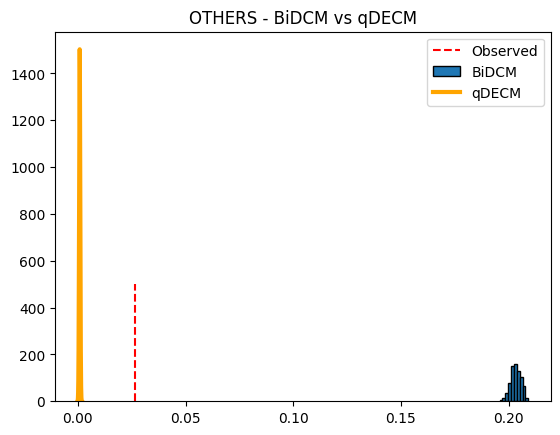

In [138]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### PD

In [139]:
blocks=guarino2dict_blocks('ita_elections', 1)

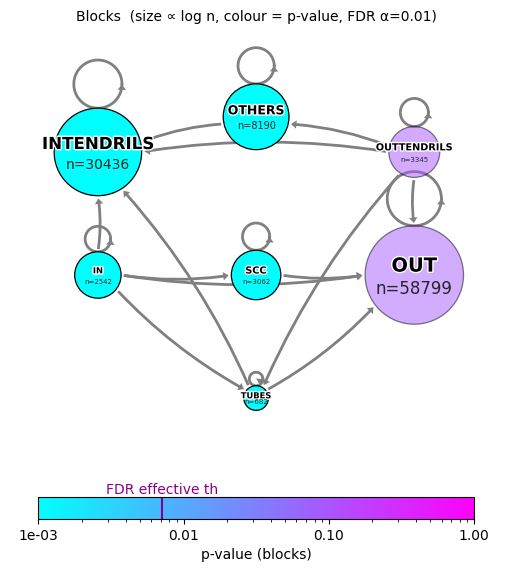

In [140]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

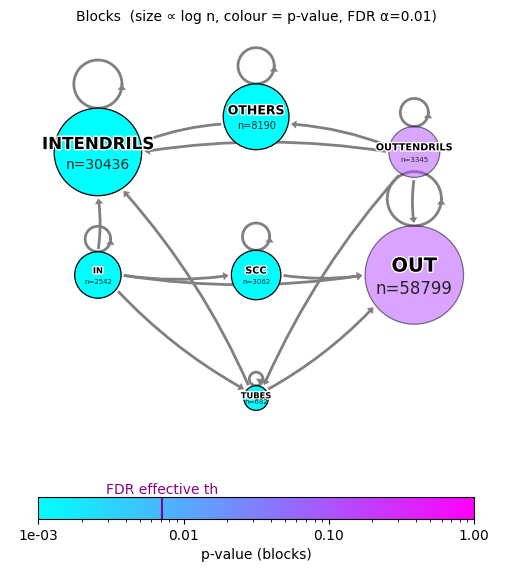

In [141]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [142]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=left
OUT: p-value=8.67e-02, tail=left
OUTTENDRILS: p-value=9.33e-02, tail=left
TUBES: p-value=0.00e+00, tail=right


In [143]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=1.40e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=1.22e-01, tail=left
IN: p-value=0.00e+00, tail=right


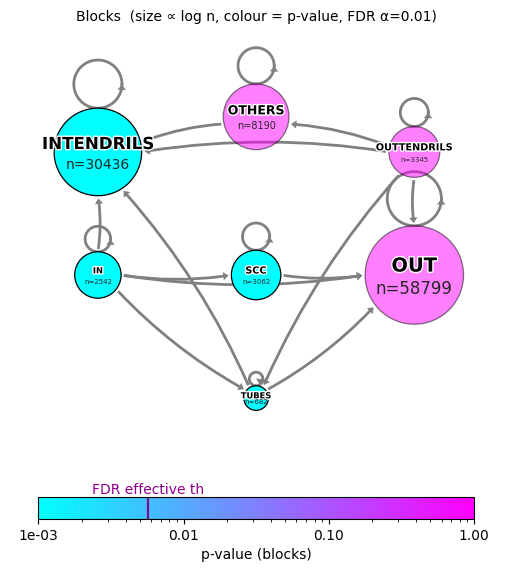

In [144]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

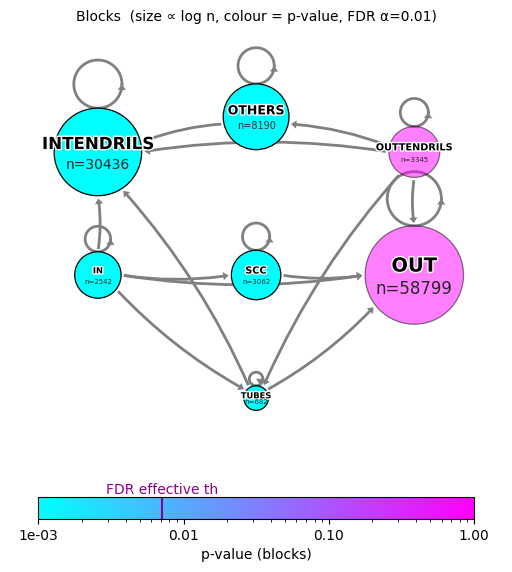

In [145]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [146]:
from scipy.stats import norm

In [147]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

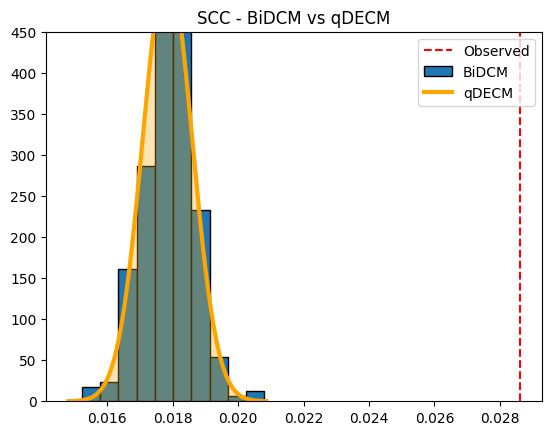

In [148]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [149]:
_block='OTHERS'

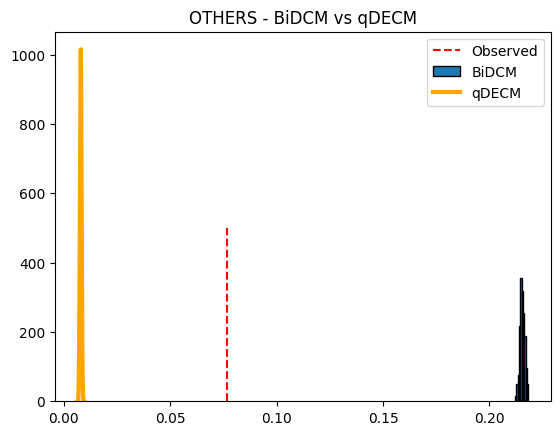

In [150]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### FI

In [151]:
blocks=guarino2dict_blocks('ita_elections', 6)

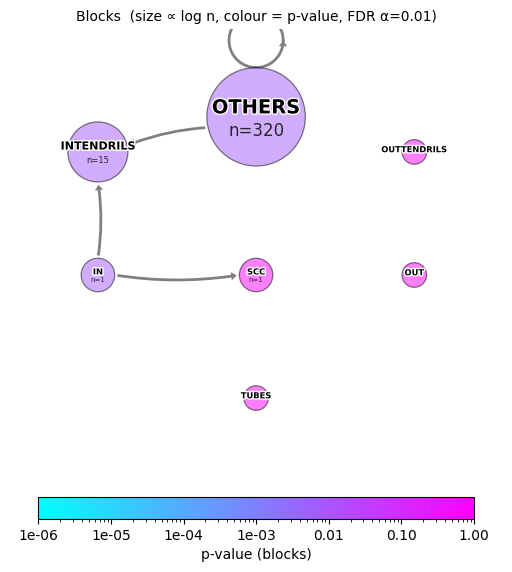

In [152]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

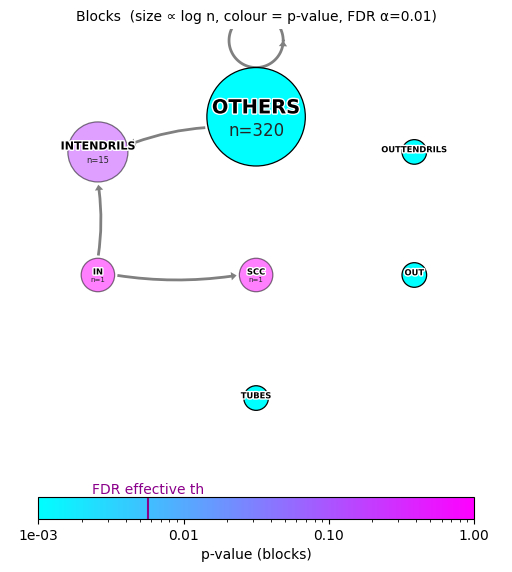

In [153]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [154]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=6.67e-03, tail=right
INTENDRILS: p-value=6.67e-03, tail=right
SCC: p-value=1.99e+00, tail=right
OTHERS: p-value=6.67e-03, tail=left
OUT: p-value=1.79e+00, tail=right
OUTTENDRILS: p-value=1.83e+00, tail=right
TUBES: p-value=2.00e+00, tail=right


In [155]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OTHERS: p-value=0.00e+00, tail=right
INTENDRILS: p-value=1.75e-01, tail=left
SCC: p-value=1.00e+00, tail=left
IN: p-value=1.00e+00, tail=left
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=left
TUBES: p-value=0.00e+00, tail=left


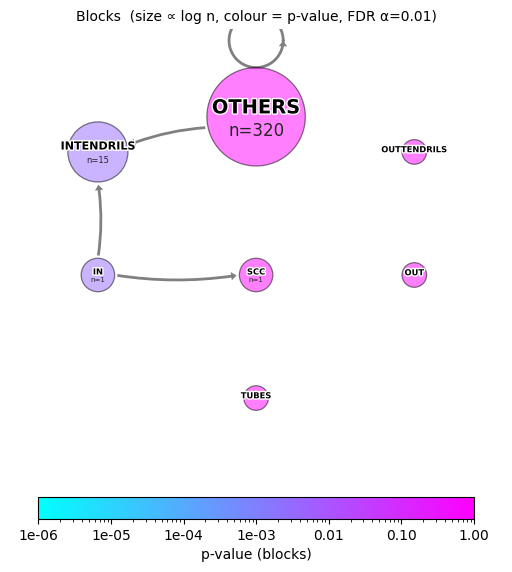

In [156]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

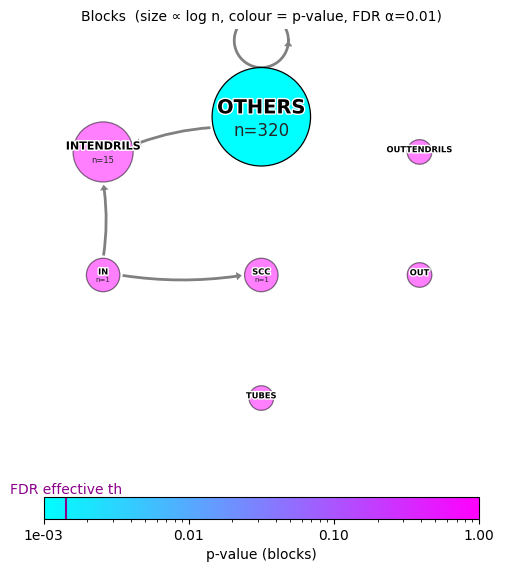

In [157]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

In [158]:
from scipy.stats import norm

In [159]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

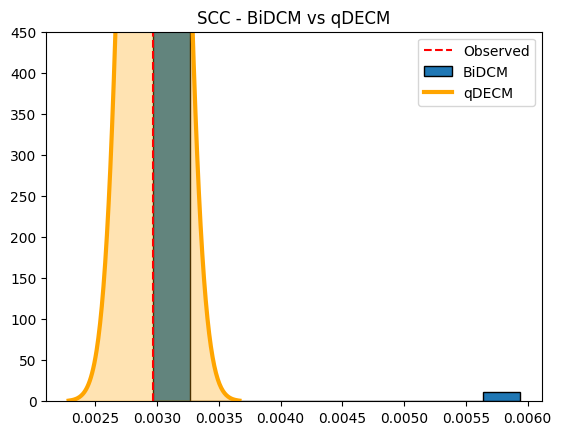

In [160]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [161]:
_block='OTHERS'

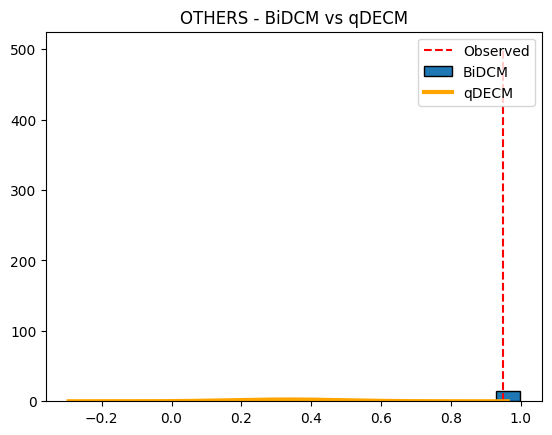

In [162]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()